In [39]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
from scipy.stats import binom
from scipy.stats import gamma
from scipy.stats import norm
from scipy.optimize import least_squares

with open("3.data",'r') as f:
        data=np.loadtxt(f)

In [40]:
#PART A
def ith_moment(dataset,i):
    return np.sum(np.power(dataset,i))/len(dataset)

moment1=ith_moment(data,1)
moment2=ith_moment(data,2)
print(moment1) #first moment
print(moment2) #second moment

6.496145618324817
46.554361807879815


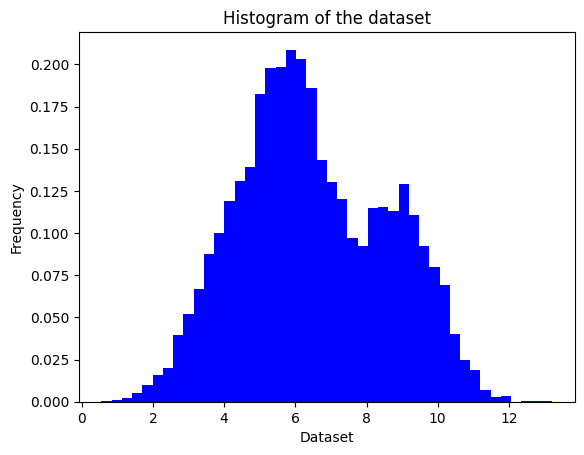

In [41]:
#PART B
plt.hist(data, bins='auto', density=True, color='blue', label='Histogram')
plt.xlabel("Dataset")
plt.ylabel("Frequency")
plt.title("Histogram of the dataset")
plt.savefig("images/3b.png")
plt.show()

#graphially normal distribution parameter form the histogram seems to be 6.

In [42]:
#PART C
#EQUATION1
def eq1_bin(n,p):
    return n*p-moment1
#EQUATION2
def eq2_bin(n,p):
    return n * (n - 1) * p**2 + n * p-moment2
def both_equations_bin(x):
    n,p=x
    return [eq1_bin(n,p),eq2_bin(n,p)]
initial_guess_bin=[1,1]
solution_bin=fsolve(both_equations_bin,initial_guess_bin)
n_sol=solution_bin[0]
p_sol=solution_bin[1]
print(n_sol,p_sol)

19.704006789304888 0.32968652963756667


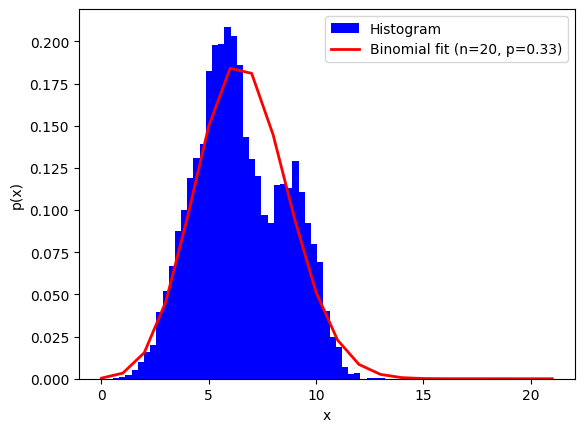

In [43]:
#After analysing both n=19 and n=20, n=20 is the best and most precise solution thus n*=20 and p*=p_sol
n=20
p=p_sol
x = np.linspace(0, n+1, 100000)
x=np.round(x)
pmf = binom.pmf(x, n, p)

# Plot histogram and PMF
plt.hist(data, bins='auto', density=True, color='blue', label='Histogram')
binom_pmf = binom.pmf(x, n, p)
plt.plot(x, binom_pmf, 'r-', lw=2, label=f'Binomial fit (n={n}, p={p:.2f})')

plt.xlabel('x')
plt.ylabel('p(x)')
plt.legend(loc='upper right')
plt.savefig("images/3c.png")
plt.show()

In [44]:
#PART D
#EQUATION1
def eq1_gamma(k,theta):
    return k*theta-moment1
#EQUATION2
def eq2_gamma(k,theta):
    return k * (k+ 1) * theta**2 -moment2
def both_equations_gamma(x):
    k,theta=x
    return [eq1_gamma(k,theta),eq2_gamma(k,theta)]
initial_guess_gamma=[1,1]
solution_gamma=fsolve(both_equations_gamma,initial_guess_gamma)
k_sol=solution_gamma[0]
theta_sol=solution_gamma[1]
print(k_sol,theta_sol)

9.691205541246163 0.6703134703624323


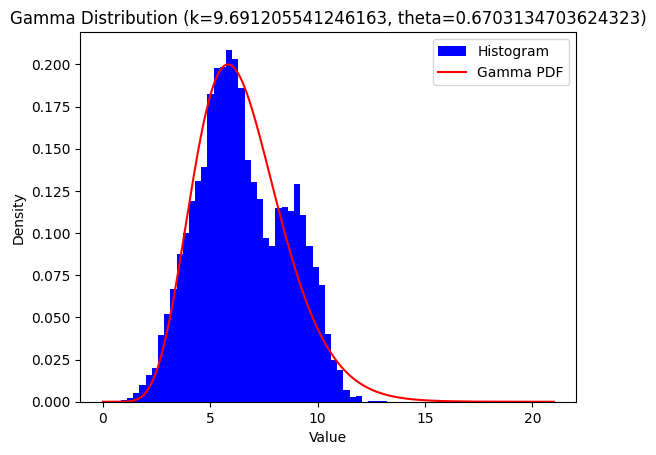

In [45]:
plt.hist(data, bins='auto', density=True, color='blue', label='Histogram')
x = np.linspace(0, n+1, 10000)
y = gamma.pdf(x, k_sol, scale=theta_sol)
plt.plot(x, y, color='red', label='Gamma PDF')
plt.xlabel('Value')
plt.ylabel('Density')
plt.title(f'Gamma Distribution (k={k_sol}, theta={theta_sol})')
plt.legend()
plt.savefig("images/3d.png")
plt.show()

In [46]:
def average_log_likelihood_binomial(data, n, p):
    data_modified = np.round(data)
    likelihoods = binom.pmf(data_modified, n, p)
    log_likelihoods = np.log(likelihoods)
    average_log_likelihood = np.mean(log_likelihoods)
    return average_log_likelihood

def average_log_likelihood_gamma(data, k, theta):
    likelihoods = gamma.pdf(data, k, scale=theta)
    log_likelihoods = np.log(likelihoods)
    average_log_likelihood = np.mean(log_likelihoods)
    return average_log_likelihood
avg_like_bin=average_log_likelihood_binomial(data,n,p)
avg_like_gamma=average_log_likelihood_gamma(data,k_sol,theta_sol)
print(avg_like_bin,avg_like_gamma)

-2.1570681154346776 -2.1608217722067953


In [47]:
#Since both the fits have almost similar average log likelihood, however binomial is slightly better fit than gamma fit
#PART F
#step 1 calculating third and forth moments
moment3=ith_moment(data,3)
moment4=ith_moment(data,4)
print(moment3,moment4)

#EQUATION1
def eq1_GMM(mu1,p1,mu2,p2):
    return p1 * mu1 + p2 * mu2 - moment1
#EQUATION2
def eq2_GMM(mu1,p1,mu2,p2):
    return p1 * (1.00 + mu1**2) + p2 * (1.00 + mu2**2) - moment2
#EQUATION3
def eq3_GMM(mu1,p1,mu2,p2):
    return p1 * (mu1**3 + 3 * mu1) + p2 * (mu2**3 + 3 * mu2) - moment3
#EQUATION4
def eq4_GMM(mu1,p1,mu2,p2):
    return p1 * (mu1**4 + 6 * (mu1**2) + 3.00) + p2 * (mu2**4 + 6 * (mu2**2) + 3.00) - moment4
def both_equations_GMM(x):
    mu1,p1,mu2,p2=x
    return [eq1_GMM(mu1,p1,mu2,p2),eq2_GMM(mu1,p1,mu2,p2),eq3_GMM(mu1,p1,mu2,p2),eq4_GMM(mu1,p1,mu2,p2)]

initial_guesses = [6,0,9,0]
solution=fsolve(both_equations_GMM,initial_guesses)
mu1,p1,mu2,p2 = solution
print(f"p1 = {p1}, mu1 = {mu1}, p2 = {p2}, mu2 = {mu2}")


360.56586952543273 2968.068491427333
p1 = 0.6118740341610936, mu1 = 5.129607694285282, p2 = 0.3826456511927248, mu2 = 8.77436305441652


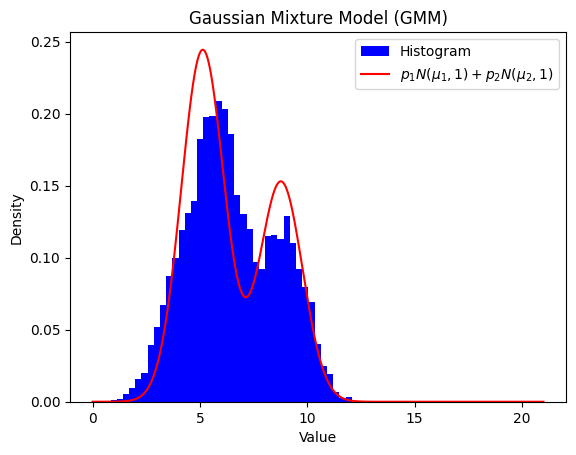

In [48]:
#Plotting GMM
x = np.linspace(0, n+1, 10000)
pdf1 = p1 * norm.pdf(x, mu1, 1)  
pdf2 = p2 * norm.pdf(x, mu2, 1) 

# Calculate the overall GMM PDF
gmm_pdf = pdf1 + pdf2

# Plot the GMM PDF and sample data
plt.hist(data, bins='auto', density=True, color='blue', label='Histogram')
plt.plot(x, gmm_pdf, color='red', label=r'$p_1 N(\mu_1, 1) + p_2 N(\mu_2, 1)$')
plt.xlabel('Value')
plt.ylabel('Density')
plt.title('Gaussian Mixture Model (GMM)')
plt.legend()
plt.savefig('images/3e.png')
plt.show()

In [49]:
def average_log_likelihood_GMM(data, p1,mu1,p2,mu2):
    pdf1 = p1 * norm.pdf(data, mu1, 1)  
    pdf2 = p2 * norm.pdf(data, mu2, 1) 
    likelihoods = pdf1+pdf2
    log_likelihoods = np.log(likelihoods)
    average_log_likelihood = np.mean(log_likelihoods)
    return average_log_likelihood

print(average_log_likelihood_GMM(data,p1,mu1,p2,mu2))

-2.1830387449113196


In [50]:
moment5=ith_moment(data,5)
moment6=ith_moment(data,6)

def eq1_GMM(mu1,p1,mu2,p2,mu3,p3):
    return p1 * mu1 + p2 * mu2 +p3*mu3- moment1
#EQUATION2
def eq2_GMM(mu1,p1,mu2,p2,mu3,p3):
    return p1 * (1.00 + mu1**2) + p2 * (1.00 + mu2**2) + p3 * (1.00 + mu3**2) - moment2
#EQUATION3
def eq3_GMM(mu1,p1,mu2,p2,mu3,p3):
    return p1 * (mu1**3 + 3 * mu1) + p2 * (mu2**3 + 3 * mu2) + p3 * (mu3**3 + 3 * mu3) - moment3
#EQUATION4
def eq4_GMM(mu1,p1,mu2,p2,mu3,p3):
    return p1 * (mu1**4 + 6 * (mu1**2) + 3.00) + p2 * (mu2**4 + 6 * (mu2**2) + 3.00) + p3 * (mu3**4 + 6 * (mu3**2) + 3.00) - moment4
def eq5_GMM(mu1,p1,mu2,p2,mu3,p3):
    return p1*(mu1**5 + 10*mu1**3+15) + p2*(mu2**5 + 10*mu2**3+15)+ p3*(mu3**5 + 10*mu3**3+15)-moment5
def eq6_GMM(mu1,p1,mu2,p2,mu3,p3):
    return p1*(mu1**6 + 15*mu1**4+45*mu1**2+15)+p2*(mu2**6 + 15*mu2**4+45*mu2**2+15)+ p3*(mu3**6 + 15*mu3**4+45*mu3**2+15) -moment6
def both_equations_GMM(x):
    mu1,p1,mu2,p2,mu3,p3=x
    return [eq1_GMM(mu1,p1,mu2,p2,mu3,p3),eq2_GMM(mu1,p1,mu2,p2,mu3,p3),eq3_GMM(mu1,p1,mu2,p2,mu3,p3),eq4_GMM(mu1,p1,mu2,p2,mu3,p3),eq5_GMM(mu1,p1,mu2,p2,mu3,p3),eq6_GMM(mu1,p1,mu2,p2,mu3,p3)]

initial_guesses = [6,0.5,9,0.3,4.1,0.2]
solution=fsolve(both_equations_GMM,initial_guesses)
mu1,p1,mu2,p2,mu3,p3 = solution
print(f"p1 = {p1}, mu1 = {mu1}, p2 = {p2}, mu2 = {mu2}, p3={p3}, mu3={mu3}")


p1 = 0.9674874836205982, mu1 = 5.281966742679565, p2 = 0.29046014868287, mu2 = 9.110922520033713, p3=-0.23830160118461216, mu3=3.5754415357349836


C:\Users\aksgu\AppData\Local\Temp\ipykernel_30840\3513823798.py:24: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  solution=fsolve(both_equations_GMM,initial_guesses)


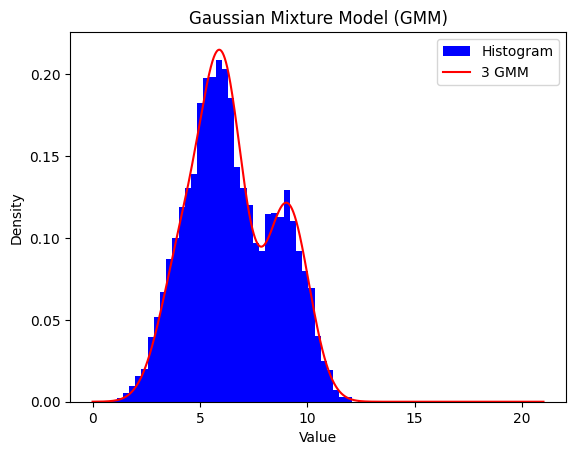

In [51]:
#Plotting GMM
p1 = 0.5018740341610936  #Obtained by hypertuning 
mu1 = 6.02960769428528
p2 = 0.2996456511927248
mu2 = 9.07436305441652
p3=0.2
mu3=4.1
x = np.linspace(0, n+1, 10000)
pdf1 = p1 * norm.pdf(x, mu1, 1)  
pdf2 = p2 * norm.pdf(x, mu2, 1) 
pdf3 = p3 * norm.pdf(x,mu3,1)
# Calculate the overall GMM PDF
gmm_pdf = pdf1 + pdf2 + pdf3

# Plot the GMM PDF and sample data
plt.hist(data, bins='auto', density=True, color='blue', label='Histogram')
plt.plot(x, gmm_pdf, color='red', label=r'3 GMM')
plt.xlabel('Value')
plt.ylabel('Density')
plt.title('Gaussian Mixture Model (GMM)')
plt.legend()
plt.savefig('images/3f.png')
plt.show()